In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import sys
import os
import matplotlib.pyplot as plt
# Locate project root automatically
def find_project_root(target='metamer_finder'):
    curr = os.path.abspath('')
    while not os.path.exists(os.path.join(curr, target)):
        parent = os.path.dirname(curr)
        if parent == curr: raise FileNotFoundError(f"Could not find {target} root.")
        curr = parent
    return curr

root_dir = find_project_root()
if root_dir not in sys.path: sys.path.append(root_dir)
from metamer_finder import MetamerOptimizer, FeatureExtractor


W0512 01:00:15.910000 29180 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
class CLIPVisionWrapper(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.model = clip_model
        
        # Differentiable normalization handled INSIDE the forward pass
        self.normalize = transforms.Normalize(
            mean=[0.48145466, 0.4578275, 0.40821073],
            std=[0.26862954, 0.26130258, 0.27577711]
        )
        
        # A dummy layer we can easily hook into with your FeatureExtractor
        self.embedding_output = nn.Identity()

    def forward(self, x):
        # x is expected to be [B, 3, 224, 224] in [0, 1] range
        x_norm = self.normalize(x)
        
        # Extract and mathematically normalize the continuous image vector
        features = self.model.get_image_features(pixel_values=x_norm)
        features = features / features.norm(p=2, dim=-1, keepdim=True)
        
        # Pass it through the dummy layer so the extractor can grab it
        return self.embedding_output(features)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load Hugging Face Models
clip_base = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

for param in clip_base.parameters():
    param.requires_grad = False

# Wrap the model
vision_model = CLIPVisionWrapper(clip_base)

In [4]:
# 2. Define the Text Target 
target_text = "A photo of a jet plane"
text_inputs = processor(text=[target_text], return_tensors="pt").to(device)

with torch.no_grad():
    target_text_features = clip_base.get_text_features(**text_inputs)
    target_text_features = target_text_features / target_text_features.norm(p=2, dim=-1, keepdim=True)

# Format exactly how MetamerOptimizer expects target features
target_dict = {"embedding_output": target_text_features}

In [5]:
# 3. Set up your existing Feature Extractor
# Hook into the Identity layer we created in the wrapper
extractor = FeatureExtractor(vision_model, target_layers=["embedding_output"])

# 4. Define the Custom Loss Hook for CLIP (Cosine Distance)
def clip_multimodal_loss(synthetic_embeds, current_features, target_features):
    """Minimizes the cosine distance between image embedding and text embedding."""
    current_vec = current_features["embedding_output"]
    target_vec = target_features["embedding_output"]
    
    similarity = torch.sum(current_vec * target_vec, dim=-1)
    # Loss is 1 - similarity (so 0 means perfectly aligned)
    return 1.0 - similarity.mean()


In [6]:
# 5. Prepare Starting Image
try:
    img = Image.open("dog.jpg").convert("RGB")
except FileNotFoundError:
    img = Image.new('RGB', (224, 224), color=(127, 127, 127))

resize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor() 
])
starting_image_tensor = resize_transform(img).unsqueeze(0).to(device)
# 6. Execute Your Optimizer
optimizer = MetamerOptimizer(
    extractor=extractor,
    target_features=target_dict,
    lr=0.01,
    max_iterations=1_000,
    custom_loss_hook=clip_multimodal_loss,
    override_base_loss=True # Ensure we only use the cosine loss
)

print(f"Generating Multimodal Metamer for: '{target_text}'...")
optimized_image = optimizer.generate(starting_image=starting_image_tensor)


Generating Multimodal Metamer for: 'A photo of a jet plane'...


Optimizing (mse): 100%|██████████| 1000/1000 [07:03<00:00,  2.36it/s, loss=0.013520]


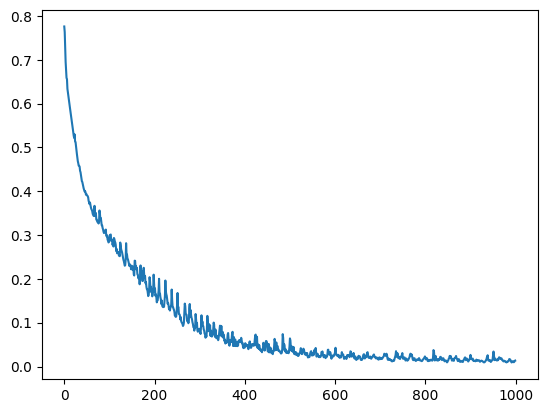

In [7]:
plt.plot(optimizer.loss_history)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


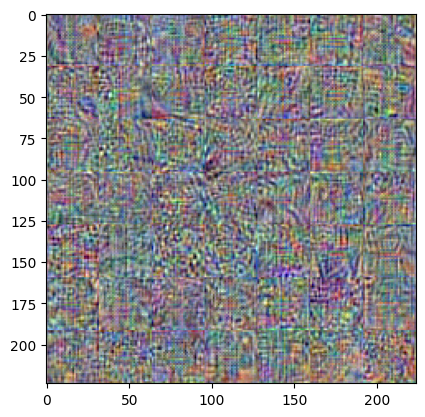

In [8]:
final_img = optimized_image.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
plt.imshow(final_img)

In [9]:
print("\nRunning Verification Pass...")

# 1. Turn off gradient tracking (crucial for inference/checking)
with torch.no_grad():
    
    # 2. Pass the raw optimized tensor through your wrapper.
    # The CLIPVisionWrapper automatically applies the exact CLIP 
    # normalization and extracts the L2-normalized image features for you!
    verified_image_features = vision_model(optimized_image)
    
    # 3. Calculate final Cosine Similarity against the text target
    final_similarity = torch.sum(verified_image_features * target_text_features, dim=-1)

print(f"Verified Final Alignment Score: {final_similarity.item():.4f}")


Running Verification Pass...
Verified Final Alignment Score: 0.9858


# BLIP

In [10]:
import torch
import torch.nn as nn
from torchvision import transforms
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

# Import your existing framework
from metamer_finder.optimizer import MetamerOptimizer
from metamer_finder.extractor import FeatureExtractor

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. SETUP & MODEL LOADING
# ==========================================
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_base = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
blip_base.eval()

for param in blip_base.parameters():
    param.requires_grad = False


In [11]:
target_text = "an image of a green fighter jet"
text_inputs = processor(text=target_text, return_tensors="pt").to(device)
target_labels = text_inputs.input_ids

In [12]:
class BLIPGenerativeWrapper(nn.Module):
    def __init__(self, model, labels):
        super().__init__()
        self.model = model
        self.target_labels = labels
        self.normalize = transforms.Normalize(
            mean=[0.48145466, 0.4578275, 0.40821073],
            std=[0.26862954, 0.26130258, 0.27577711]
        )
        # Dummy layer for the extractor to latch onto
        self.loss_output = nn.Identity()

    def forward(self, x):
        # 1. Normalize differentiably
        x_norm = self.normalize(x)
        
        # 2. TEACHER FORCING: Pass both image and labels. 
        # Hugging Face automatically computes the Cross-Entropy text loss.
        outputs = self.model(pixel_values=x_norm, 
                             input_ids=self.target_labels,
                             labels=self.target_labels)
        
        # 3. Extract the scalar loss and reshape it so the FeatureExtractor can grab it
        loss_tensor = outputs.loss.view(1, 1) 
        return self.loss_output(loss_tensor)

# Initialize the wrapper
vision_model = BLIPGenerativeWrapper(blip_base, target_labels)

In [13]:
extractor = FeatureExtractor(vision_model, target_layers=["loss_output"])

# Define the "Passthrough" Loss Hook
# Since the wrapper already computed the complex text generation loss, 
# this hook just returns it directly sto the optimizer.
def blip_generative_loss(synthetic_embeds, current_features, target_features):
    return current_features["loss_output"].mean()

# The GUI expects a target feature dictionary to initialize, so we pass a dummy zero tensor
target_dict = {"loss_output": torch.zeros((1, 1), device=device)}

In [14]:
img = Image.new('RGB', (384, 384), color=(127, 127, 127))

resize_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor() 
])
starting_image_tensor = resize_transform(img).unsqueeze(0).to(device)

# Execute Your Optimizer
optimizer = MetamerOptimizer(
    extractor=extractor,
    target_features=target_dict,
    lr=0.02,
    max_iterations=100,
    custom_loss_hook=blip_generative_loss,
    override_base_loss=True
)

print(f"Commencing search for: '{target_text}'...")
optimized_image = optimizer.generate(starting_image=starting_image_tensor)


Commencing search for: 'an image of a green fighter jet'...


Optimizing (mse): 100%|██████████| 100/100 [01:45<00:00,  1.05s/it, loss=0.139868]


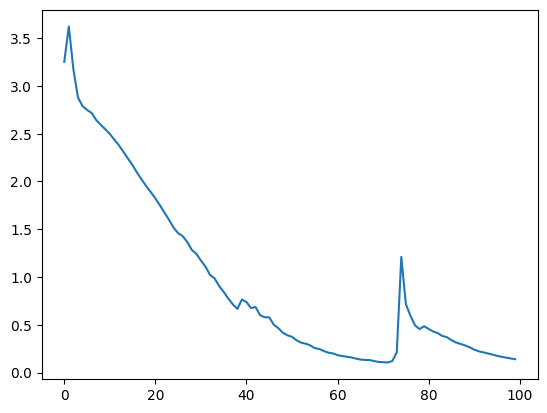

In [15]:
plt.plot(optimizer.loss_history)

In [16]:
print("\nVerifying the Metamer's Generative Output...")
with torch.no_grad():
    # Apply the exact normalization the model expects
    verified_normalized = vision_model.normalize(optimized_image)
    
    # Generate text from scratch based solely on the optimized pixels
    generated_ids = blip_base.generate(pixel_values=verified_normalized, max_length=50)
    generated_caption = processor.decode(generated_ids[0], skip_special_tokens=True)

print(f"Target Sentence Expected:  '{target_text}'")
print(f"Model Actually Generated:  '{generated_caption}'")


Verifying the Metamer's Generative Output...
Target Sentence Expected:  'an image of a green fighter jet'
Model Actually Generated:  'an image of a green fighter jet'


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Plotting results...


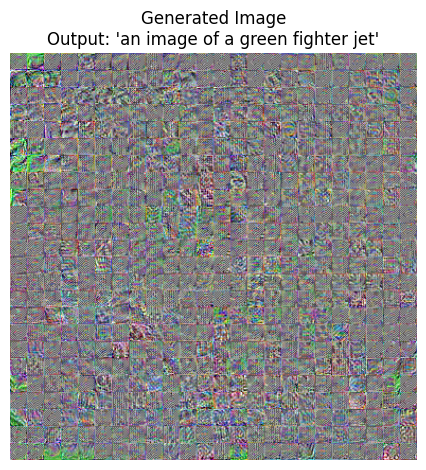

In [17]:
import matplotlib.pyplot as plt


print("\nPlotting results...")

# 1. Format the Original Image
# Remove batch dimension, move to CPU, and shuffle axes from [C, H, W] to [H, W, C]
original_np = starting_image_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()

# 2. Format the Optimized Metamer
# We MUST use .detach() here to severe it from the gradient graph before converting to numpy
metamer_np = optimized_image.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

# 3. Plotting
# Right Subplot: Metamer
plt.imshow(metamer_np)
# We use the text we extracted in the verification step as the title!
plt.title(f"Generated Image\nOutput: '{generated_caption}'")
plt.axis("off")

plt.tight_layout()
plt.show()